<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">

# **Análisis de Series de Tiempo II**
# **Clase 8, Fine-tuning de Chronos-2**

Tomamos un foundation model que ya pronostica zero-shot y lo fine-tuneamos con nuestros datos.


Dataset: **ETTh1** (7 series horarias reales).

Este bloque instala lo necesario y reinicia Colab.

In [ ]:
!pip install -q "autogluon.timeseries>=1.4"
!pip uninstall -y -q torchao

import os
print("Listo. Reiniciando…")
os.kill(os.getpid(), 9)

Importamos lo necesario

In [ ]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

Definimos parámetros

In [ ]:
H = 24 # horizonte: 24 horas
SERIES = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

Cargamos el dataset.

AutoGluon quiere formato largo: una fila por (serie, timestamp)

In [ ]:
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

raw = pd.read_csv(URL, parse_dates=["date"]).rename(columns={"date": "timestamp"})
largo = raw.melt(id_vars="timestamp", value_vars=SERIES, var_name="item_id", value_name="target")
tsdf = TimeSeriesDataFrame.from_data_frame(largo, id_column="item_id", timestamp_column="timestamp")

Holdout temporal, las últimas H horas de cada serie no se usan para entrenar

In [ ]:
train, test = tsdf.slice_by_timestep(None, -H), tsdf

In [ ]:
predictor = TimeSeriesPredictor(
    prediction_length=H,
    target="target",
    eval_metric="MASE", # error relativo al naive estacional: MASE < 1 = le gana al naive
    freq="h",
).fit(
    train_data=train,
    hyperparameters={
        "Chronos2": [
            {"ag_args": {"name_suffix": "ZeroShot"}}, # el checkpoint sin tocar

            {"fine_tune": True, # el mismo checkpoint, ajustado con LoRA
             "fine_tune_lr": 1e-4, # LR bajo: ajustamos, no entrenamos de cero
             "fine_tune_steps": 500, # más pasos = más riesgo de sobreajuste
             "ag_args": {"name_suffix": "FineTuned"}},
        ]
    },
    time_limit=1800,
    enable_ensemble=False, # queremos comparar los dos, no mezclarlos
)

Beginning AutoGluon training... Time limit = 1800s
AutoGluon will save models to '/content/AutogluonModels/ag-20260821_211131'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       11.51 GB / 12.67 GB (90.8%)
Disk Space Avail:   63.93 GB / 112.64 GB (56.8%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'freq': 'h',
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': 'ZeroShot'}},
                                  {'ag_args': {'name_suffix': 'FineTuned'},
                                   'fine_tune': True,
                                   'fine_tune_lr': 

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

	-0.7372       = Validation score (-MASE)
	10.28   s     = Training runtime
	0.95    s     = Validation (prediction) runtime
Training timeseries model Chronos2FineTuned. Training for up to 1786.2s of the 1786.2s of remaining time.


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

	-0.7645       = Validation score (-MASE)
	515.90  s     = Training runtime
	0.70    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2ZeroShot', 'Chronos2FineTuned']
Total runtime: 527.88 s
Best model: Chronos2ZeroShot
Best model score: -0.7372


Comparamos

Tres puntos importantes al leer el leaderboard:
- los scores están negados (más alto = mejor): MASE 0.66 aparece como -0.66
- AutoGluon ordena por score_test pero elige por score_val, la que decide es validación
- si un modelo falla, lo salta y devuelve el leaderboard sin él

In [ ]:
lb = predictor.leaderboard(test)
mase = -lb.set_index("model")[["score_val", "score_test"]]
mase.columns = ["MASE validación", "MASE test"]
mase["Fit (s)"] = lb.set_index("model").fit_time_marginal.round(0)
print(mase.round(4).to_string(), "\n")

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

                   MASE validación  MASE test  Fit (s)
model                                                 
Chronos2ZeroShot            0.7372     0.6637     10.0
Chronos2FineTuned           0.7645     0.7188    516.0 



* La compuerta: se promueve solo si mejora en validación por un margen mínimo
* Una mejora del 1% es ruido, y cambiar el modelo en producción nunca es gratis

In [ ]:
MARGEN = 0.03
campeon, challenger = "Chronos2ZeroShot", "Chronos2FineTuned"

if challenger not in mase.index:
    print(f"{challenger} falló durante el entrenamiento (revisar el warning de la celda 2).")
else:
    v_c, v_ch = mase.loc[campeon, "MASE validación"], mase.loc[challenger, "MASE validación"]
    mejora = (v_c - v_ch) / v_c
    print(f"mejora del fine-tuning en validación: {mejora:+.1%}  (margen exigido: {MARGEN:.0%})")
    if mejora >= MARGEN:
        print(f"Promover {challenger}. Guardar rollback a {campeon}.")
    else:
        print(f"Se mantiene {campeon}: la mejora no justifica mantener un artefacto entrenado.")

mejora del fine-tuning en validación: -3.7%  (margen exigido: 3%)
Se mantiene Chronos2ZeroShot: la mejora no justifica mantener un artefacto entrenado.


Vemos los pronósticos

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

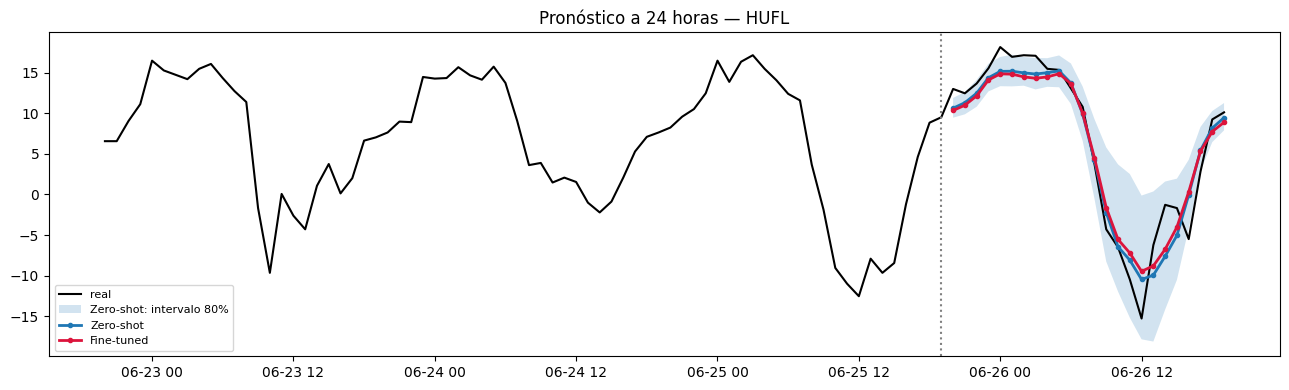

In [ ]:
import matplotlib.pyplot as plt

SERIE = "HUFL"
zs = predictor.predict(train, model="Chronos2ZeroShot").loc[SERIE]
real = test.loc[SERIE].target.tail(H * 4)

plt.figure(figsize=(13, 4))
plt.plot(real.index, real.values, color="black", lw=1.5, label="real")
plt.fill_between(zs.index, zs["0.1"], zs["0.9"], alpha=.2, label="Zero-shot: intervalo 80%")
plt.plot(zs.index, zs["mean"], lw=2, marker="o", ms=3, label="Zero-shot")

if "Chronos2FineTuned" in lb.model.values:
    ft = predictor.predict(train, model="Chronos2FineTuned").loc[SERIE]
    plt.plot(ft.index, ft["mean"], color="crimson", lw=2, marker="o", ms=3, label="Fine-tuned")

plt.axvline(train.loc[SERIE].index.max(), color="gray", ls=":")
plt.title(f"Pronóstico a {H} horas — {SERIE}"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()